In [1]:
import numpy as np
import time
A = np.array([[5,-1,-1,-1],[-1,-5,-1,1],[1,-1,5,-1],[1,-1,5,-1]], float)
b=np.array([10,20,30,40],float)

def jacobi_matrices(A,b, tol):
  #declarar vector inicial
  x0=np.array([1,0,1,0],float)
  D=np.diag(np.diag(A))
  U= D-np.triu(A)
  L=D-np.tril(A)

  #Matriz Tjacobi
  T_jab=np.dot(np.linalg.inv(D),L+U)
  c_jab=np.dot(np.linalg.inv(D),b)

  eigvalues, eigvectores = np.linalg.eig(T_jab)
  radio_espectral=max(abs(eigvalues))

  if (radio_espectral >= 1):
    print('El sistema iterativo no converge para ningun valor inicial :()')
    return
  else:
    error = 1
    cont=0
    tiempo_inicial=time.time()
    while error > tol:
      cont+=1
      x1 = np.dot(T_jab,x0)+c_jab
      #print(x1)
      error = max(abs(x1-x0))
      if cont == 3:
        print(x1)
      x0=x1
    tiempo_final=time.time()
    tiempo_total=tiempo_final-tiempo_inicial
    return x1, cont, tiempo_total

In [2]:
A=np.array([[3,-1,0,0],[-1,-3,1,0],[0,1,3,-1],[0,0,-1,-3]],float)
b=np.array([12,12,10,10],float)
jacobi_matrices(A, b, 1e-6)

[ 2.59259259 -3.74074074  3.25925926 -4.48148148]


(array([ 2.71559651, -3.85321071,  3.15596301, -4.38532129]),
 24,
 0.0030341148376464844)

Jacobi sumas


In [3]:
import numpy as np

A = np.array([[10,-3,5],[-2,-13,7],[4,-8,15]], float)
b=np.array([12,23,14],float)
print(A)
#Matriz E.D.D
n=len(b)
for i in range(n):
  aux=(sum(abs(A[i,0:n]))-abs(A[i,i]))
  if (abs(A[i,i]) >=aux):
    print('ok')



[[ 10.  -3.   5.]
 [ -2. -13.   7.]
 [  4.  -8.  15.]]
ok
ok
ok


In [4]:
#Viernes 27/03

import numpy as np
import time

A = np.array([[10,-3,5],[-2,-13,7],[4,-8,15]], float)
b=np.array([12,23,14],float)
#print(A)

x0=np.ones_like(b)
def jacobi_sumas(A,b,x0,tol):
  Nmax=50
  conteo=0
  error = 1
  x_new=np.zeros_like(b)
  while error > tol and conteo<Nmax:
    for i in range(len(b)):
      suma=0
      for j in range(len(b)):
        if j!=i:
          suma+=A[i,j]*x0[j]
      x_new[i] = (b[i]-suma) / A[i,i]
    conteo+=1
    print(x_new)
    error = max(abs(x_new-x0))
    x0=x_new.copy()
  return x_new, conteo


In [5]:
start=time.time()
jacobi_sumas(A,b,x0,1e-4)
end=time.time()
tiempo_ex = end-start
print('Tiempo de ejecucion es: ', tiempo_ex)

[ 1.         -1.38461538  1.2       ]
[ 0.18461538 -1.27692308 -0.07179487]
[ 0.85282051 -1.83629191  0.20307692]
[ 0.54757396 -1.79108481 -0.27344116]
[ 0.79939513 -2.00071046 -0.16793162]
[ 0.68375267 -1.98263936 -0.34688428]
[ 0.77865033 -2.06120733 -0.30640837]
[ 0.73484198 -2.05401225 -0.37361733]
[ 0.77060499 -2.08346195 -0.35809773]
[ 0.75401028 -2.08060724 -0.38334104]
[ 0.76748835 -2.09164675 -0.37739327]
[ 0.76120261 -2.09051766 -0.38687516]
[ 0.76628228 -2.09465626 -0.38459678]
[ 0.76390151 -2.09421093 -0.38815861]
[ 0.76581603 -2.09576256 -0.38728623]
[ 0.76491435 -2.09558736 -0.38862431]
[ 0.76563595 -2.09616914 -0.38829042]
[ 0.76529447 -2.09610037 -0.38879313]
[ 0.76556645 -2.09631853 -0.38866539]
[ 0.76543714 -2.09629159 -0.38885427]
[ 0.76553966 -2.0963734  -0.38880542]
[ 0.76549069 -2.09636286 -0.38887639]
Tiempo de ejecucion es:  0.0033550262451171875


In [6]:
T = np.array([[4,-1,0,-1],[-1,4,-1,0],[0,-1,4,-1], [-1,0,-1,4]], float)
b2=np.array([190,20,35,145],float)
t0=np.zeros_like(b2)
Temperatura, iter=jacobi_sumas(T,b2,t0,1e-4)

[47.5   5.    8.75 36.25]
[57.8125 19.0625 19.0625 50.3125]
[64.84375 24.21875 26.09375 55.46875]
[67.421875 27.734375 28.671875 58.984375]
[69.1796875 29.0234375 30.4296875 60.2734375]
[69.82421875 29.90234375 31.07421875 61.15234375]
[70.26367188 30.22460938 31.51367188 61.47460938]
[70.42480469 30.44433594 31.67480469 61.69433594]
[70.53466797 30.52490234 31.78466797 61.77490234]
[70.57495117 30.57983398 31.82495117 61.82983398]
[70.60241699 30.59997559 31.85241699 61.84997559]
[70.61248779 30.6137085  31.86248779 61.8637085 ]
[70.61935425 30.6187439  31.86935425 61.8687439 ]
[70.62187195 30.62217712 31.87187195 61.87217712]
[70.62358856 30.62343597 31.87358856 61.87343597]
[70.62421799 30.62429428 31.87421799 61.87429428]
[70.62464714 30.62460899 31.87464714 61.87460899]
[70.6248045  30.62482357 31.8748045  61.87482357]
[70.62491179 30.62490225 31.87491179 61.87490225]
[70.62495112 30.62495589 31.87495112 61.87495589]


<function matplotlib.pyplot.show(close=None, block=None)>

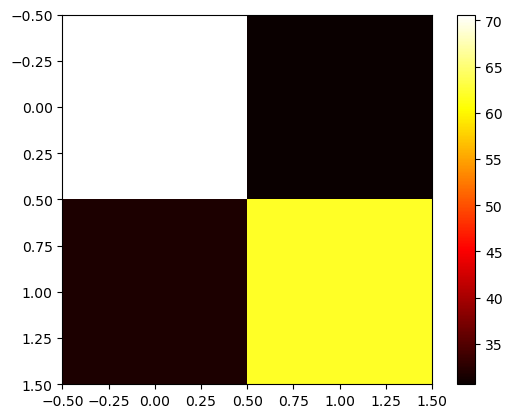

In [7]:
import matplotlib.pyplot as plt
data = Temperatura.reshape(2,2)
fig, ax = plt.subplots()
im = ax.imshow(data, cmap=plt.get_cmap('hot'))
fig.colorbar(im)
plt.show